# Forward-only throughput: gradsolve against DiffEqGPU.jl

This notebook times a forward-only ensemble solve (no gradient) for gradsolve's fused kernels and
for DiffEqGPU.jl's fused `GPUTsit5` kernel on the same GPU, at several tolerances, and reports the
accuracy each arm actually reached.

**Problem.** A Lorenz ensemble (sigma = 10, beta = 8/3, rho swept over [0, 21], y0 = (1, 0, 0),
t in [0, 1]), the configuration used by the published GPU ODE benchmarks. Double precision throughout.

**Arms.**
- *gradsolve cuda_tsit5*: the hand-written CUDA Tsit5 kernel (`engine="cuda_tsit5"`; needs `nvcc`).
- *gradsolve warp_ode*: the fused adaptive Tsit5 kernel in NVIDIA Warp (`engine="warp_ode"`).
- *DiffEqGPU.jl GPUTsit5*: the fused kernel through `DiffEqGPU.vectorized_asolve`, adaptive, run by
  the Julia script `forward_vs_diffeqgpu/bench_diffeqgpu.jl` when a `julia` executable is available
  (`julia --project=benchmarks/forward_vs_diffeqgpu -e 'using Pkg; Pkg.instantiate()'` once).

**Protocol.** One untimed warm-up call, then the best of several timed calls. On a GPU the gradsolve
arms are timed at the kernel launch, with inputs and outputs resident on the device, through the
engines' JAX FFI entry points; that is the same boundary as DiffEqGPU's `vectorized_asolve`
(BenchmarkTools' minimum of a CUDA-synchronised call). The time through the public `gradsolve.solve`,
which adds the copies between host and device and the Python overhead, is shown alongside as
"through gradsolve.solve". Accuracy is the median relative error of the final
state on an evenly spaced subsample of 4096 trajectories against a scipy DOP853 reference at
rtol 1e-11. Where both arms cover an error, DiffEqGPU's time per trajectory is interpolated
(log-log) onto the error gradsolve achieved and the ratio is read there.

**Run it.** Set the environment variables below before starting the kernel (or use the
command-line twin `python benchmarks/forward_vs_diffeqgpu.py --device cuda --n 2048 32768 524288`).
The committed outputs come from a run on one NVIDIA H200 (hardware line printed by the first cell).


In [1]:
import os, pathlib, subprocess, sys

REPO = pathlib.Path.cwd()
while not (REPO / "benchmarks" / "forward_vs_diffeqgpu.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "benchmarks"))

import jax
import pandas as pd
import forward_vs_diffeqgpu as bench

NS = [int(x) for x in os.environ.get("GRADSOLVE_BENCH_NS", "2048").split()]
RTOLS = [float(x) for x in os.environ.get("GRADSOLVE_BENCH_RTOLS", "1e-3 1e-4 1e-6 1e-8").split()]
REPEATS = int(os.environ.get("GRADSOLVE_BENCH_REPEATS", "5"))
DEVICE = os.environ.get("GRADSOLVE_BENCH_DEVICE", "cpu")
JULIA = os.environ.get("GRADSOLVE_JULIA", "auto")      # a path, "auto" (search PATH) or "none"
OUT = str(REPO / "benchmarks" / "results")

print("jax", jax.__version__, "devices:", jax.devices())
try:
    print("GPU:", subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version", "--format=csv,noheader"],
                                 capture_output=True, text=True, timeout=10).stdout.strip().splitlines()[0])
except Exception:
    print("GPU: none visible")
print(f"ensemble sizes {NS}, tolerances {RTOLS}, best of {REPEATS}, device {DEVICE}, julia {bench.find_julia(JULIA)}")


jax 0.10.2 devices: [CudaDevice(id=0)]
GPU: NVIDIA H200 NVL, 610.57.04
ensemble sizes [2048, 8192, 32768, 131072, 524288], tolerances [0.001, 0.0001, 1e-06, 1e-08], best of 5, device cuda, julia /data/aspuriom/gradsolve-bench/juliaup/bin/julia


In [2]:
rows = bench.run(NS, RTOLS, REPEATS, DEVICE, JULIA, OUT)


n = 2048: scipy reference on 2048 trajectories ...


  n=2048 rtol=1e-03 gradsolve cuda_tsit5       0.104 ms  0.05078 us/traj (kernel; through gradsolve.solve 0.23007)  err 1.05e-03
Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H200 NVL" (140 GiB, sm_90, mempool enabled)
   Kernel cache:
     /data/aspuriom/gradsolve-bench/.cache/warp/1.15.0
Module gradsolve.warp._warp_kernel 244dd66 load on device 'cuda:0' took 13.11 ms  (cached)
  n=2048 rtol=1e-03 gradsolve warp_ode         0.130 ms  0.06371 us/traj (kernel; through gradsolve.solve 0.42216)  err 1.05e-03
  n=2048 rtol=1e-04 gradsolve cuda_tsit5       0.111 ms  0.05437 us/traj (kernel; through gradsolve.solve 0.23736)  err 1.58e-04
  n=2048 rtol=1e-04 gradsolve warp_ode         0.139 ms  0.06781 us/traj (kernel; through gradsolve.solve 0.42918)  err 1.58e-04
  n=2048 rtol=1e-06 gradsolve cuda_tsit5       0.141 ms  0.06898 us/traj (kernel; through gradsolve.solve 0.25591)  err 3.17e-07
  n=2048 rtol=1e-06 grad

  n=8192 rtol=1e-03 gradsolve cuda_tsit5       0.105 ms  0.01284 us/traj (kernel; through gradsolve.solve 0.06952)  err 1.05e-03
  n=8192 rtol=1e-03 gradsolve warp_ode         0.134 ms  0.01631 us/traj (kernel; through gradsolve.solve 0.11665)  err 1.05e-03
  n=8192 rtol=1e-04 gradsolve cuda_tsit5       0.111 ms  0.01351 us/traj (kernel; through gradsolve.solve 0.06865)  err 1.58e-04
  n=8192 rtol=1e-04 gradsolve warp_ode         0.139 ms  0.01702 us/traj (kernel; through gradsolve.solve 0.11262)  err 1.58e-04
  n=8192 rtol=1e-06 gradsolve cuda_tsit5       0.146 ms  0.01777 us/traj (kernel; through gradsolve.solve 0.07323)  err 3.17e-07
  n=8192 rtol=1e-06 gradsolve warp_ode         0.180 ms  0.02201 us/traj (kernel; through gradsolve.solve 0.11942)  err 3.17e-07
  n=8192 rtol=1e-08 gradsolve cuda_tsit5       0.215 ms  0.02625 us/traj (kernel; through gradsolve.solve 0.08524)  err 1.01e-09
  n=8192 rtol=1e-08 gradsolve warp_ode         0.274 ms  0.03346 us/traj (kernel; through gradsol

  n=32768 rtol=1e-03 gradsolve cuda_tsit5       0.104 ms  0.00317 us/traj (kernel; through gradsolve.solve 0.02674)  err 1.05e-03
  n=32768 rtol=1e-03 gradsolve warp_ode         0.134 ms  0.00410 us/traj (kernel; through gradsolve.solve 0.03486)  err 1.05e-03
  n=32768 rtol=1e-04 gradsolve cuda_tsit5       0.114 ms  0.00348 us/traj (kernel; through gradsolve.solve 0.02614)  err 1.58e-04
  n=32768 rtol=1e-04 gradsolve warp_ode         0.137 ms  0.00418 us/traj (kernel; through gradsolve.solve 0.03453)  err 1.58e-04
  n=32768 rtol=1e-06 gradsolve cuda_tsit5       0.148 ms  0.00453 us/traj (kernel; through gradsolve.solve 0.02772)  err 3.17e-07
  n=32768 rtol=1e-06 gradsolve warp_ode         0.180 ms  0.00548 us/traj (kernel; through gradsolve.solve 0.03600)  err 3.17e-07
  n=32768 rtol=1e-08 gradsolve cuda_tsit5       0.235 ms  0.00716 us/traj (kernel; through gradsolve.solve 0.03082)  err 1.01e-09
  n=32768 rtol=1e-08 gradsolve warp_ode         0.280 ms  0.00854 us/traj (kernel; through

  n=131072 rtol=1e-03 gradsolve cuda_tsit5       0.142 ms  0.00108 us/traj (kernel; through gradsolve.solve 0.02033)  err 1.05e-03
  n=131072 rtol=1e-03 gradsolve warp_ode         0.163 ms  0.00124 us/traj (kernel; through gradsolve.solve 0.02063)  err 1.05e-03
  n=131072 rtol=1e-04 gradsolve cuda_tsit5       0.159 ms  0.00122 us/traj (kernel; through gradsolve.solve 0.02038)  err 1.58e-04
  n=131072 rtol=1e-04 gradsolve warp_ode         0.185 ms  0.00141 us/traj (kernel; through gradsolve.solve 0.02043)  err 1.58e-04
  n=131072 rtol=1e-06 gradsolve cuda_tsit5       0.247 ms  0.00189 us/traj (kernel; through gradsolve.solve 0.02291)  err 3.17e-07
  n=131072 rtol=1e-06 gradsolve warp_ode         0.283 ms  0.00216 us/traj (kernel; through gradsolve.solve 0.02094)  err 3.17e-07


...

  n=524288 rtol=1e-08 gradsolve cuda_tsit5       1.424 ms  0.00272 us/traj (kernel; through gradsolve.solve 0.01613)  err 1.01e-09
  n=524288 rtol=1e-08 gradsolve warp_ode         1.571 ms  0.00300 us/traj (kernel; through gradsolve.solve 0.01556)  err 1.01e-09
  /data/aspuriom/gradsolve-bench/juliaup/bin/julia --project=/data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu /data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu/bench_diffeqgpu.jl /data/aspuriom/gradsolve-bench/repo/benchmarks/results 0.001 2048 8192 32768 131072 524288


  n=2048 rtol=1e-03 DiffEqGPU.jl GPUTsit5      0.060 ms  0.02946 us/traj  err 4.72e-04
  n=8192 rtol=1e-03 DiffEqGPU.jl GPUTsit5      0.061 ms  0.00743 us/traj  err 4.73e-04
  n=32768 rtol=1e-03 DiffEqGPU.jl GPUTsit5      0.070 ms  0.00214 us/traj  err 4.73e-04
  n=131072 rtol=1e-03 DiffEqGPU.jl GPUTsit5      0.212 ms  0.00162 us/traj  err 4.73e-04
  n=524288 rtol=1e-03 DiffEqGPU.jl GPUTsit5      0.748 ms  0.00143 us/traj  err 4.73e-04
  /data/aspuriom/gradsolve-bench/juliaup/bin/julia --project=/data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu /data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu/bench_diffeqgpu.jl /data/aspuriom/gradsolve-bench/repo/benchmarks/results 0.0001 2048 8192 32768 131072 524288


  n=2048 rtol=1e-04 DiffEqGPU.jl GPUTsit5      0.078 ms  0.03823 us/traj  err 2.88e-05
  n=8192 rtol=1e-04 DiffEqGPU.jl GPUTsit5      0.079 ms  0.00959 us/traj  err 2.87e-05
  n=32768 rtol=1e-04 DiffEqGPU.jl GPUTsit5      0.090 ms  0.00275 us/traj  err 2.87e-05
  n=131072 rtol=1e-04 DiffEqGPU.jl GPUTsit5      0.273 ms  0.00208 us/traj  err 2.87e-05
  n=524288 rtol=1e-04 DiffEqGPU.jl GPUTsit5      0.983 ms  0.00187 us/traj  err 2.87e-05
  /data/aspuriom/gradsolve-bench/juliaup/bin/julia --project=/data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu /data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu/bench_diffeqgpu.jl /data/aspuriom/gradsolve-bench/repo/benchmarks/results 1e-06 2048 8192 32768 131072 524288


  n=2048 rtol=1e-06 DiffEqGPU.jl GPUTsit5      0.150 ms  0.07319 us/traj  err 1.00e-07
  n=8192 rtol=1e-06 DiffEqGPU.jl GPUTsit5      0.150 ms  0.01834 us/traj  err 1.00e-07
  n=32768 rtol=1e-06 DiffEqGPU.jl GPUTsit5      0.176 ms  0.00538 us/traj  err 1.00e-07
  n=131072 rtol=1e-06 DiffEqGPU.jl GPUTsit5      0.525 ms  0.00401 us/traj  err 1.00e-07
  n=524288 rtol=1e-06 DiffEqGPU.jl GPUTsit5      1.922 ms  0.00367 us/traj  err 1.00e-07
  /data/aspuriom/gradsolve-bench/juliaup/bin/julia --project=/data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu /data/aspuriom/gradsolve-bench/repo/benchmarks/forward_vs_diffeqgpu/bench_diffeqgpu.jl /data/aspuriom/gradsolve-bench/repo/benchmarks/results 1e-08 2048 8192 32768 131072 524288


  n=2048 rtol=1e-08 DiffEqGPU.jl GPUTsit5      0.316 ms  0.15433 us/traj  err 2.42e-10
  n=8192 rtol=1e-08 DiffEqGPU.jl GPUTsit5      0.317 ms  0.03865 us/traj  err 2.42e-10
  n=32768 rtol=1e-08 DiffEqGPU.jl GPUTsit5      0.367 ms  0.01121 us/traj  err 2.42e-10
  n=131072 rtol=1e-08 DiffEqGPU.jl GPUTsit5      1.150 ms  0.00878 us/traj  err 2.42e-10
  n=524288 rtol=1e-08 DiffEqGPU.jl GPUTsit5      4.240 ms  0.00809 us/traj  err 2.42e-10


In [3]:
table = pd.DataFrame(rows)[["n", "rtol", "arm", "err", "ms", "us_per_traj", "us_per_traj_api", "timing"]]
table.columns = ["n", "rtol", "arm", "achieved error (median rel.)", "ms per solve", "us per trajectory",
                 "us per trajectory through gradsolve.solve", "timing boundary"]
table


,n,rtol,arm,achieved error (median rel.),ms per solve,us per trajectory,us per trajectory through gradsolve.solve,timing boundary
0,2048,1.000000e-03,gradsolve cuda_tsit5,1.050056e-03,0.103993,0.050778,0.230066,kernel
1,2048,1.000000e-03,gradsolve warp_ode,1.050056e-03,0.130468,0.063705,0.422160,kernel
2,2048,1.000000e-04,gradsolve cuda_tsit5,1.575444e-04,0.111342,0.054366,0.237356,kernel
3,2048,1.000000e-04,gradsolve warp_ode,1.575444e-04,0.138880,0.067812,0.429182,kernel
4,2048,1.000000e-06,gradsolve cuda_tsit5,3.171153e-07,0.141264,0.068977,0.255907,kernel
5,2048,1.000000e-06,gradsolve warp_ode,3.171153e-07,0.175140,0.085518,0.448231,kernel
6,2048,1.000000e-08,gradsolve cuda_tsit5,1.007069e-09,0.218940,0.106904,0.287752,kernel
7,2048,1.000000e-08,gradsolve warp_ode,1.007069e-09,0.276338,0.134931,0.488056,kernel
8,8192,1.000000e-03,gradsolve cuda_tsit5,1.050837e-03,0.105184,0.012840,0.069515,kernel
9,8192,1.000000e-03,gradsolve warp_ode,1.050837e-03,0.133643,0.016314,0.116653,kernel


In [4]:
ratios = pd.DataFrame(bench.matched_ratios(rows))
ratios["ratio_matched"] = ratios["ratio_matched"].map(
    lambda r: f"{r:.2f}" if r == r else "outside DiffEqGPU's measured error range")
ratios.columns = ["n", "rtol", "arm", "achieved error", "us per trajectory", "DiffEqGPU time / gradsolve time at matched accuracy"]
ratios


,n,rtol,arm,achieved error,us per trajectory,DiffEqGPU time / gradsolve time at matched accuracy
0,2048,1.000000e-03,gradsolve cuda_tsit5,1.050056e-03,0.050778,outside DiffEqGPU's measured error range
1,2048,1.000000e-03,gradsolve warp_ode,1.050056e-03,0.063705,outside DiffEqGPU's measured error range
2,2048,1.000000e-04,gradsolve cuda_tsit5,1.575444e-04,0.054366,0.60
3,2048,1.000000e-04,gradsolve warp_ode,1.575444e-04,0.067812,0.48
4,2048,1.000000e-06,gradsolve cuda_tsit5,3.171153e-07,0.068977,0.93
5,2048,1.000000e-06,gradsolve warp_ode,3.171153e-07,0.085518,0.75
6,2048,1.000000e-08,gradsolve cuda_tsit5,1.007069e-09,0.106904,1.21
7,2048,1.000000e-08,gradsolve warp_ode,1.007069e-09,0.134931,0.96
8,8192,1.000000e-03,gradsolve cuda_tsit5,1.050837e-03,0.012840,outside DiffEqGPU's measured error range
9,8192,1.000000e-03,gradsolve warp_ode,1.050837e-03,0.016314,outside DiffEqGPU's measured error range


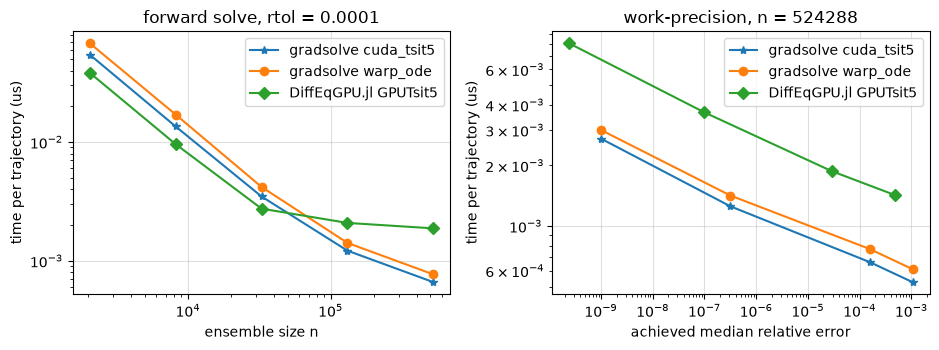

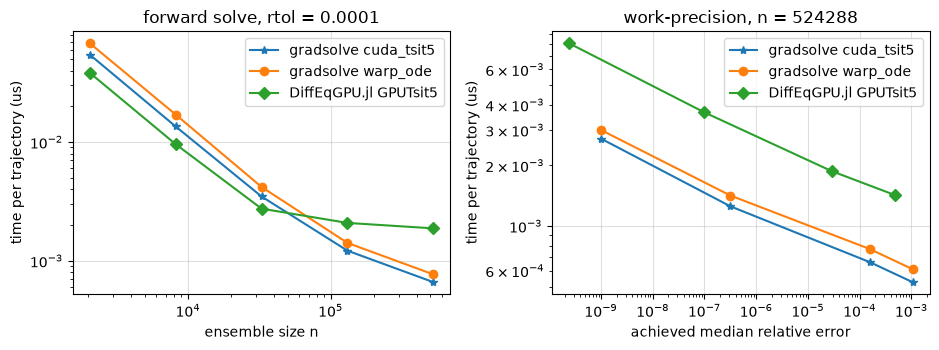

In [5]:
fig = bench.plot(rows)
fig


## Reading the result

The left panel is time per trajectory against ensemble size at one tolerance; per-trajectory cost
falls until the GPU is saturated and then flattens. The right panel is the work-precision view at
the largest ensemble: time per trajectory against the accuracy actually reached, so a method that
is fast because it is loose sits to the right, not below. The ratio table reads DiffEqGPU's cost at
the accuracy gradsolve achieved; a ratio above one means gradsolve is faster there.

The two libraries do not use the same step-size controller, so at the same requested tolerance
they reach different accuracies; that is why the comparison is read at matched achieved error.

On the H200 run committed here, at the same requested tolerance gradsolve's fused kernels take two
to three times less per trajectory than DiffEqGPU.jl's at the largest ensembles. DiffEqGPU.jl's step
controller reaches a tighter error for the same tolerance, so read at matched achieved accuracy the
picture depends on the ensemble size: at 131,072 and 524,288 trajectories gradsolve's kernels are
1.3 to 2.6 times faster, while at 32,768 and below both kernels are launch-bound and the ratio runs
from about 0.5 to 1.3, so DiffEqGPU.jl is the faster one at the loosest tolerances there. The ratio
table above is the number to quote. gradsolve's loosest rows (rtol 1e-3) reach an error looser than
any DiffEqGPU.jl setting in the sweep, so they carry a label instead of a ratio.
